# Flux analysis using Escher

First, let us enable a `logger`.

In [2]:
import logging

# Create a custom logger
logger = logging.getLogger('my_logger')

# Configure the logger
logger.setLevel(logging.DEBUG)  # Set the minimum level of messages to log
handler   = logging.StreamHandler()  # Create a handler to output to the console
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)


Escher is rather funny with its dependencies and its documentation is not the best one. 
I was only able of making this work thanks to a reply by [danolson1](https://github.com/zakandrewking/escher/issues/348#issuecomment-883426701) in a relative issue. 


<!-- self-note: 
conda activate me21 
-->


In [5]:
import escher
from escher import Builder
import cobra
from time import sleep

ModuleNotFoundError: No module named 'cobra'

In [ ]:
escher.

In [3]:
escher.__version__

'1.7.3'

Load libraries needed to parse a **KEGG map**.

In [ ]:
# Check if a package is installed; for example:
!pip show Bio
# Then, install package if not installed
!pip install Bio==1.83
!pip install requests-cache==0.9.5
!pip install pykegg==0.1.7
!pip install networkx==3.1
!pip install matplotlib==3.7.3
!pip install plotnine==0.12.4

In [4]:
from Bio.KEGG import REST
from Bio.KEGG.KGML import KGML_parser
from io import StringIO

In [5]:
# Load some common libraries
import os, re
import json
import pandas as pd

In [32]:
# To use with pykegg
import pykegg
from PIL import Image
import requests_cache
import numpy as np


# To visualize with pykegg
from plotnine import (
    ggplot,
    geom_segment,
    options,
    geoms,
    aes,
    geom_segment,
    theme_void,
    geom_rect,
    geom_text,

)


In [18]:
import xml.etree.ElementTree as ET
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt

In [19]:
from collections import defaultdict  # for the function that builds the conversion dfs

In [20]:
ecoli_modelfile = "../github_repos/KU/fluxpy/ext_data/models/e_coli_core.json"

In [21]:
escher.rc['never_ask_before_quit'] = True

In [ ]:
escher.list_available_maps()

In [ ]:
escher.list_available_models()

In [ ]:
builder1 = Builder(
    model_json="../github_repos/KU/fluxpy/ext_data/models/e_coli_core.json"
)

In [ ]:
builder1.reaction_data

In [ ]:
builder1

To show how escher works, I am using the e_coli_core model and the central metabolism map of the iJO1366 model in the same `builder` object. 
I can then optimize the model and assign the flux values returned on the map. 
Escher will not return any errors, it will just assign the flux values to any reactions sharing names/ids between the two models.!

In [129]:
builder2 = Builder(
    map_name='e_coli_core.Core metabolism',
    model_name='e_coli_core',
)

In [130]:
builder2

Builder(never_ask_before_quit=True)

> When running the following commnads, check the changes in the above map!

First, we will **change** the map. 

In [ ]:
builder2.map_name = 'iJO1366.Central metabolism'

In [ ]:
builder2.model_name = 'e_coli_core'

Find any reactions that are in the map and not in the model, and turn them red

In [ ]:
builder2.highlight_missing = True

In [ ]:
builder2.model = cobra.io.load_json_model('../github_repos/KU/fluxpy/ext_data/models/e_coli_core.json')

In [ ]:
# Run FBA with the model and add the flux data to the map
solution = builder2.model.optimize()
builder2.reaction_data = solution.fluxes

In [ ]:
# Add some data for metabolites
builder2.metabolite_data = solution.shadow_prices

In [ ]:
builder3 = Builder(
    height=600, 
    map_name=None, 
    model_name='e_coli_core',
    map_json='https://escher.github.io/1-0-0/5/maps/Escherichia%20coli/e_coli_core.Core%20metabolism.json',
)
builder3

In [ ]:
model = cobra.io.load_json_model(ecoli_modelfile)

In [ ]:
reverse = False
step = 0.1
timestep = 0.1
duration = 15 # seconds
lim = [0, 0.5]
val = lim[-1]


for _ in range(int(duration / timestep)):
    
    # Set o2 lower bound     
    model.reactions.EX_o2_e.lower_bound = -val
    
    # Solve an FBA
    solution = model.optimize()

    # Update reaction_data based on the flux vector from FBA
    builder3.reaction_data = solution.fluxes

    if val <= lim[0]:
        reverse = True
    
    if val >= lim[1]:
        reverse = False
    
    if reverse:
        val += step
    
    else:
        val -= step
    
    sleep(timestep)
    
    print(_, val)

In [ ]:
builder3

### KEGG reactions stoichiometry

In [ ]:
metanex_path="/home/luna.kuleuven.be/u0156635/github_repos/KU/microbetag/microbetagDB/mappings/MetaNetX"
with open(os.path.join(metanex_path, "reactions/keggR.tsv")) as f:
    metanex_kegg_reac = f.readlines()

In [ ]:
kegg_stoichiometry = {}

for react in metanex_kegg_reac:

    react = react.strip()
    react_id = react.split("\t")[0].split(":")[1]
    react = react.split("||")[-1]
    reactants, products = react.strip().split("<=> ")

    pattern   = r'(?<=:)(.*?)(?=@)'
    reactants = [ (re.search(pattern, reactant)[0], reactant.strip().split(" ")[0]) for reactant in reactants.split("+")]
    products  = [ (re.search(pattern, product)[0], product.strip().split(" ")[0]) for product in products.split("+")]

    rs = { r[0]: -int(r[1]) for r in reactants }
    ps = { p[0]: int(p[1]) for p in products }
    rs.update(ps)

    kegg_stoichiometry[react_id] = rs

    # Just to check how it looks
print(list(kegg_stoichiometry.items())[:2])

### KEGG, BiGG, ModelSEED compounds

Read each ontology file (we have splitted them using `grep`) and use the metanetx id to map from one to the other.

In [ ]:
def parse_definition_file(file):
    """
    file: "compounds/seed_compound.tsv"
    """
    onto2metanetx = {}
    with open(os.path.join(metanex_path, file)) as f:
        ontology_terms = f.readlines()
    for term in ontology_terms:
        onto_id, metanetx_id = term.split("\t")[:2]
        onto_id = onto_id.split(":")[-1]
        onto2metanetx[onto_id] = metanetx_id
    return onto2metanetx

Make a 3-columns dataframe using the metanetx id and the corresponding ids for the three other ontologies.

In [ ]:
def build_namespace_df(kegg_dic, bigg_dic, seed_dic):
    """
    e.g.,
    kegg_dic: kegg2metanetx
    """
    # Create a defaultdict to store all keys for duplicated values
    duplicates_dict = defaultdict(list)

    # Add keys from seed2metanetx
    for key, value in seed_dic.items():
        duplicates_dict[value].append(('seed2metanetx', key))

    # Add keys from bigg2metanetx
    for key, value in bigg_dic.items():
        duplicates_dict[value].append(('bigg2metanetx', key))

    # Add keys from kegg2metanetx
    for key, value in kegg_dic.items():
        duplicates_dict[value].append(('kegg2metanetx', key))

    # Convert defaultdict to list of tuples for DataFrame creation
    data = []
    for value, keys in duplicates_dict.items():
        for dictionary, key in keys:
            data.append((value, dictionary, key))

    # Create DataFrame
    namespace_df = pd.DataFrame(data, columns=['metanetx_id', 'namespace', 'id'])

    return namespace_df

In [ ]:
kegg2metanetx = parse_definition_file("compounds/kegg_compound.tsv")
bigg2metanetx = parse_definition_file("compounds/bigg_metabolite.tsv")
seed2metanetx = parse_definition_file("compounds/seed_compound.tsv")

In [ ]:
compounds_namespaces = build_namespace_df(kegg2metanetx, bigg2metanetx, seed2metanetx)

Similarly, we need to build the corresponding data frame for the **reactions** case.

In [ ]:
kegg2metanetx = parse_definition_file("reactions/kegg_reaction.tsv")
bigg2metanetx = parse_definition_file("reactions/bigg_reaction_reac.tsv")
seed2metanetx = parse_definition_file("reactions/seed_reaction.tsv")

In [ ]:
reactions_namespaces = build_namespace_df(kegg2metanetx, bigg2metanetx, seed2metanetx)
reactions_namespaces.tail()

### Get all BiGG mets and rxns in default Escher maps

In [ ]:
all_bigg_rxns = {}
all_bigg_mets = {}

for emap in escher.list_available_maps():
    print("hello friend")
    try:
        print("clear cashe")
        Builder.close_all()
    except:
        pass

    builder = Builder(map_name = emap["map_name"])

    # THIS IS THE FUNCTION THAT CAN GIE US THE REACTIONS AND THE METABOLITES
    f = builder._loaded_map_json
    map_json = json.loads(f)
    map_json_metadata = map_json[0]
    map_json_items = map_json[1]

    map_rxns = map_json_items["reactions"]
    map_mets = map_json_items["nodes"]

    for react_id, react in map_rxns.items():
        if react_id not in all_bigg_rxns:
            all_bigg_rxns[react_id] = react
        else:
            print(react_id)

    for met_id, met in map_mets.items():
        if met_id not in all_bigg_mets:
            all_bigg_mets[met_id] = met
        else:
            print("node:", met_id)

In [ ]:
unique_bigg_rxn_ids = []
for escher_id, react in all_bigg_rxns.items():
    if react["bigg_id"] not in unique_bigg_ids:
        unique_bigg_rxn_ids.append(escher_id)
    else:
        print(escher_id)

In [ ]:
unique_bigg_met_ids = []
for escher_id, react in all_bigg_mets.items():
    if "bigg_id" in react:
        if react["bigg_id"] not in unique_bigg_ids:
            unique_bigg_met_ids.append(escher_id)
        else:
            print(escher_id)

No duplicate bigg ids were found! So, **perfect**!

Let us see an example of a bigg metabolite:

In [ ]:
all_bigg_mets["668411"]

And a reaction:

In [ ]:
counter = 0
for rxn in all_bigg_rxns.values():
    if rxn["gene_reaction_rule"] != "":
        counter += 1
print(counter, "BiGG reactions out of", len(all_bigg_rxns), "bring a gene_reaction_rule")

In [ ]:
all_bigg_rxns["667215"].keys()

## Build an Escher map based on a KEGG one

OK, but which KEGG map to choose to start from ? 

We will access maps that correspond to a certain species, expecting that this map will be also close to our GEM. 
To this end, you may visit [KEGG organirms](https://www.genome.jp/brite/br08611) to get the code-letter for the closest species to your GEM. For example, our *Salmonella* strain is close to the serovar Typhimurium LT2, thus we will go with the `stm` maps.

First, let's have a look in an Escher map (`.json`) file

In [ ]:
with open("ecoli_map.json") as f:
    example_esher_map = json.load(f)

This is a 2 elements list:

In [ ]:
example_esher_map[0]

In [ ]:
example_esher_map[1].keys()

A node looks like this, where 1576485 is the `node_id`.

In [ ]:
example_esher_map[1]["nodes"]['1576485']

And a reaction (involving the `atp_c` metabolite) like this:

In [ ]:
example_esher_map[1]["reactions"]['1576706']

Those are both exactly the same (apparently) as in the `all_bigg_*` dictionaries we built above. 

Except from the `metabolite` case for `node_type`, there is also the `multimarker` and the `midmarker`.

In [25]:
## Be sure to cache all the downloaded files to avoid recursive querying
requests_cache.install_cache('pykegg_cache')
# g = pykegg.KGML_graph(pid="ec00010")


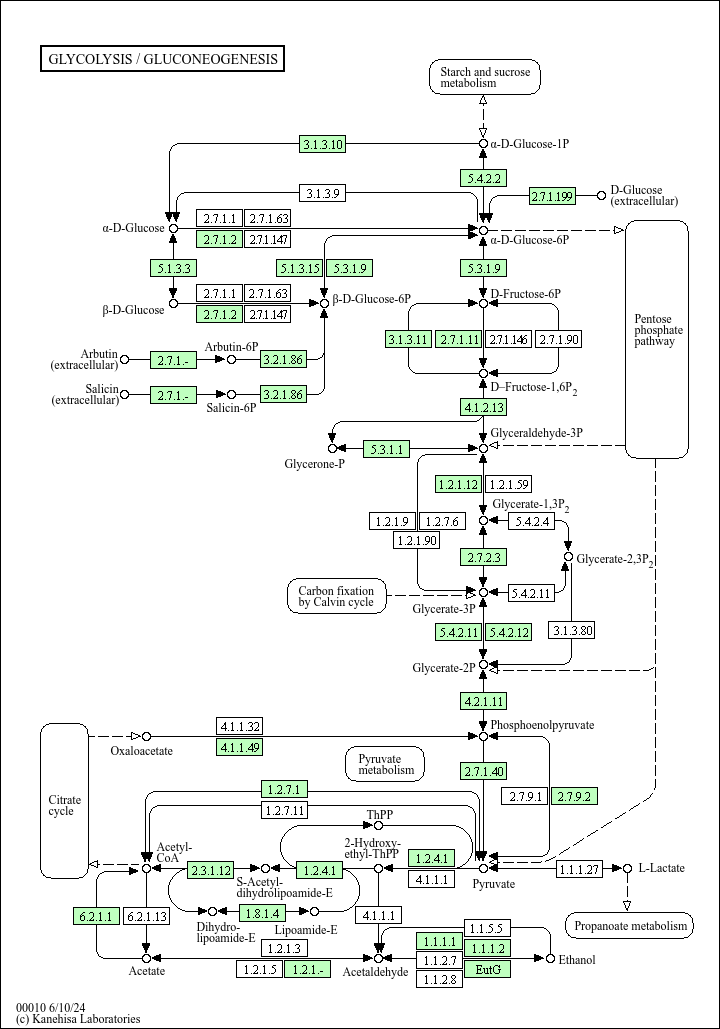

In [147]:
## Make sure to cache all the downloaded files to avoid recursive connection
requests_cache.install_cache('pykegg_cache')
# graph = pykegg.KGML_graph(pid="hsa03460")
graph = pykegg.KGML_graph(pid="stm00010")
## Overlay to raw image
nds = graph.get_nodes()
# This will give color to the 
nds["color"] = nds["bgcolor"]


# ## Assign random color
# nds = nds[nds.original_type=="gene"]
# nds["lfc"] = np.arange(-2,2,0.01)[0:nds.shape[0]]
# cmap_grad = mpl.colors.LinearSegmentedColormap.from_list("cmap_grad", ["yellow","green"])
# norm = mpl.colors.Normalize(vmin=min(nds.lfc), vmax=max(nds.lfc))
# nds["color"] = [
#         mpl.colors.to_hex(cmap_grad(norm(x))) if x is not None else None
#         for x in nds.lfc
#     ]
# Image.fromarray(pykegg.overlay_opencv_image(nds, pid="hsa03460"))
Image.fromarray(pykegg.overlay_opencv_image(nds, pid="stm00010"))

In [70]:
set(node_df.original_type.to_list())

{'compound', 'gene', 'map', 'ortholog'}

In [121]:
node_df = graph.get_nodes()
print(set(node_df["original_type"].to_list()))
print(set(node_df["type"].to_list()))
node_df[node_df["id"] == 73]

{'map', 'ortholog', 'gene', 'compound'}
{'rectangle', 'roundrectangle', 'circle'}


,id,name,x,y,graphics_name,coords,type,width,height,fgcolor,bgcolor,group,original_type,xmin,xmax,ymin,ymax,pathway_name
19,73.0,stm:STM0773 stm:STM4020,173.0,-268.0,galM...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,132.0,214.0,-280.0,-256.0,path:stm00010


In [125]:
node_df[node_df["original_type"] == "gene"]

,id,name,x,y,graphics_name,coords,type,width,height,fgcolor,bgcolor,group,original_type,xmin,xmax,ymin,ymax,pathway_name
0,18.0,stm:STM2141 stm:STM3068,483.0,-407.0,fbaB...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,442.0,524.0,-419.0,-395.0,path:stm00010
1,49.0,stm:STM4486,487.0,-948.0,yjgB,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,446.0,528.0,-960.0,-936.0,path:stm00010
2,50.0,stm:STM1567 stm:STM1627 stm:STM1749 stm:STM4044,439.0,-941.0,adhP...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,398.0,480.0,-953.0,-929.0,path:stm00010
3,52.0,stm:STM0152,431.0,-858.0,aceE,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,390.0,472.0,-870.0,-846.0,path:stm00010
4,53.0,stm:STM0152,319.0,-870.0,aceE,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,278.0,360.0,-882.0,-858.0,path:stm00010
5,54.0,stm:STM0153,210.0,-870.0,aceF,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,169.0,251.0,-882.0,-858.0,path:stm00010
6,57.0,stm:STM1378 stm:STM1888,483.0,-771.0,pykF...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,442.0,524.0,-783.0,-759.0,path:stm00010
7,59.0,stm:STM2952,483.0,-701.0,eno,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,442.0,524.0,-713.0,-689.0,path:stm00010
8,60.0,stm:STM0772 stm:STM4585,458.0,-632.0,gpmA...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,417.0,499.0,-644.0,-620.0,path:stm00010
9,61.0,stm:STM1290,458.0,-484.0,gapA,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,417.0,499.0,-496.0,-472.0,path:stm00010


In [100]:
edges_df = graph.get_edges()
edges_df

,entry1,entry2,type,subtypes,reaction
0,73,74,ECrel,"[(compound, 90)]",None
1,73,77,ECrel,"[(compound, 90)]",None
2,70,73,ECrel,"[(compound, 91)]",None
3,70,85,ECrel,"[(compound, 93)]",None
4,70,86,ECrel,"[(compound, 93)]",None
...,...,...,...,...,...
122,104,102,None,None,rn:R01196
123,45,104,None,None,rn:R00235
124,89,97,None,None,rn:R01518
125,105,45,None,None,rn:R00711


In [119]:
segments_df = pykegg.return_segments(graph, node_df)
segments_df

# segments_df[(segments_df["entry1"]==73) & (segments_df["entry2"]==74)]

,x,y,xend,yend,entry1,entry2,type,subtypes,reaction
0,173.0,-268.0,219.0,-239.0,73,74,ECrel,"[(compound, 90)]",None
1,173.0,-268.0,322.0,-144.0,73,77,ECrel,"[(compound, 90)]",None
2,219.0,-314.0,173.0,-268.0,70,73,ECrel,"[(compound, 91)]",None
3,219.0,-314.0,283.0,-359.0,70,85,ECrel,"[(compound, 93)]",None
4,219.0,-314.0,283.0,-394.0,70,86,ECrel,"[(compound, 93)]",None
...,...,...,...,...,...,...,...,...,...
122,146.0,-868.0,483.0,-868.0,104,102,None,None,rn:R01196
123,146.0,-958.0,146.0,-868.0,45,104,None,None,rn:R00235
124,483.0,-664.0,483.0,-592.0,89,97,None,None,rn:R01518
125,378.0,-958.0,146.0,-958.0,105,45,None,None,rn:R00711


In [106]:
set(segments_df["type"].to_list())

{'ECrel', None, 'maplink'}

In [107]:
node_df[node_df["original_type"]=="gene"].head()

,id,name,x,y,graphics_name,coords,type,width,height,fgcolor,bgcolor,group,original_type,xmin,xmax,ymin,ymax,pathway_name
0,18.0,stm:STM2141 stm:STM3068,483.0,-407.0,fbaB...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,442.0,524.0,-419.0,-395.0,path:stm00010
1,49.0,stm:STM4486,487.0,-948.0,yjgB,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,446.0,528.0,-960.0,-936.0,path:stm00010
2,50.0,stm:STM1567 stm:STM1627 stm:STM1749 stm:STM4044,439.0,-941.0,adhP...,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,398.0,480.0,-953.0,-929.0,path:stm00010
3,52.0,stm:STM0152,431.0,-858.0,aceE,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,390.0,472.0,-870.0,-846.0,path:stm00010
4,53.0,stm:STM0152,319.0,-870.0,aceE,None,rectangle,46.0,17.0,#000000,#BFFFBF,None,gene,278.0,360.0,-882.0,-858.0,path:stm00010


In [90]:
node_df.iloc[0]

id                                  18.0
name             stm:STM2141 stm:STM3068
x                                  483.0
y                                 -407.0
graphics_name                    fbaB...
coords                              None
type                           rectangle
width                               46.0
height                              17.0
fgcolor                          #000000
bgcolor                          #BFFFBF
group                               None
original_type                       gene
xmin                               442.0
xmax                               524.0
ymin                              -419.0
ymax                              -395.0
pathway_name               path:stm00010
Name: 0, dtype: object

From the ModelSEEDDatabase repository and the Biochemistry folder, we may get the `Unique_ModelSEED_Reaction_ECs.txt` file which looks like this:

In [56]:
!head 

ModelSEED ID	External ID	Source
rxn00001	3.6.1.1	Enzyme Class
rxn00002	3.5.1.54	Enzyme Class
rxn00003	2.2.1.6	Enzyme Class
rxn00004	4.1.3.17	Enzyme Class
rxn00006	1.11.1.21	Enzyme Class
rxn00006	1.11.1.6	Enzyme Class
rxn00007	3.2.1.28	Enzyme Class
rxn00008	1.11.1.13	Enzyme Class
rxn00009	2.7.7.45	Enzyme Class


In [60]:
modelseed2EC = pd.read_csv(
    "/home/luna.kuleuven.be/u0156635/software/ModelSEEDDatabase/Biochemistry/Aliases/Unique_ModelSEED_Reaction_ECs.txt",
    sep="\t"
)

In [61]:
modelseed2EC

,ModelSEED ID,External ID,Source
0,rxn00001,3.6.1.1,Enzyme Class
1,rxn00002,3.5.1.54,Enzyme Class
2,rxn00003,2.2.1.6,Enzyme Class
3,rxn00004,4.1.3.17,Enzyme Class
4,rxn00006,1.11.1.21,Enzyme Class
...,...,...,...
30784,rxn48570,1.6.5.9,Enzyme Class
30785,rxn48571,1.3.5.1,Enzyme Class
30786,rxn48572,2.1.1.163,Enzyme Class
30787,rxn48573,3.5.1.88,Enzyme Class


In [ ]:
# Fetch the pathway KGML file
pathway_id = 'stm00010' # Example pathway ID for Glycolysis / Gluconeogenesis
kgml_data = REST.kegg_get(pathway_id, "kgml").read()

# Parse the KGML file
pathway = KGML_parser.read(StringIO(kgml_data))


In [ ]:
kegg_map = pathway
kegg_map.title

In [ ]:
reactions_namespaces[reactions_namespaces["id"]=="R_PPS"]
reactions_namespaces[reactions_namespaces["id"]=="PPS"]

In [ ]:

for reac_id, reac in all_bigg_rxns.items():
    if reac["bigg_id"] == "PPS":
        print(reac)
        print(reac_id)
        print("-----")



In [128]:
def kegg_to_escher(KEGG_pathway):

    escher_map = [{
        'homepage': 'https://escher.github.io',
        "schema": "https://escher.github.io/escher/jsonschema/1-0-0#",
        "map_id": "00001",
        "map_name": pathway.title,
        "map_description": f"A metabolic map for Escher: https://escher.github.io based on KEGG pathway map for {KEGG_pathway.title}",
    },
    ]
    escher_items = {
        'reactions': {},
        'nodes': [],
        'text_labels': [],
        'canvas': {'x': 0, 'y': 0, 'width': 1000, 'height': 1000}
    }

    requests_cache.install_cache('pykegg_cache')

    kgml_graph    = pykegg.KGML_graph(pid=KEGG_pathway)
    nodes_df = kgml_graph.get_nodes()
    map_df   = nodes_df[node_df["original_type"] == "map"]

    return map_df
    
    
    # Get list of kegg reaction ids 
    # and primary nodes based on the 'substrate' and 'product' fields of the reaction entries
    primary_node_ids = set()
    kegg_reactions = {}
    kegg_unmatched_rxns = set()
    kegg_compounds = set()
    non_mapped_rxns = 0
    for reaction in pathway.reactions:
        kegg_reaction_id = reaction.name.split(":")[-1]
        try:
            kegg_reactions[kegg_reaction_id] = kegg_stoichiometry[kegg_reaction_id]
            for ko in kegg_stoichiometry[kegg_reaction_id]:
                kegg_compounds.add(ko)
        except:
            logger.info(f"{kegg_reaction_id} not available in BiGG.")
            kegg_unmatched_rxns.add(kegg_reaction_id)
            non_mapped_rxns += 1
        for substrate in reaction.substrates:
            primary_node_ids.add(substrate.id)
        for product in reaction.products:
            primary_node_ids.add(product.id)

    # Let's move on with the nodes    
    node_id_mapping = {}
    for entry in pathway.entries.values():

        # Map the KEGG compound to its BiGG corresponding one - if any
        if entry.type == 'compound' or entry.type == 'map' or entry.type == 'gene' :
            node_id = entry.id
            
            bigg_met = None

            if entry.type == 'compound':
                kegg_compound = entry.name.split(":")[-1]

                mapping_metanetx = compounds_namespaces[
                    compounds_namespaces["id"] == kegg_compound
                ]["metanetx_id"]

                bigg_met = compounds_namespaces[
                    (compounds_namespaces["metanetx_id"]== mapping_metanetx.item())
                    &
                     (compounds_namespaces["namespace"]=="bigg2metanetx")
                ]["id"]  
                print(kegg_compound , bigg_met)
                if len(bigg_met) == 1:
                    bigg_met = bigg_met.item()
                elif len(bigg_met) == 0:
                    bigg_met = "NA"
                else:
#                     for v in bigg_met:
#                         d = v
                    bigg_met = list(bigg_met)[-1]

            node_id_mapping[node_id] = len(escher_items['nodes']) + 1
            x = entry.graphics[0].x
            y = -entry.graphics[0].y  # Invert y for correct orientation
            label_x = x + 20  # Offset label to the right of the node
            label_y = y
            escher_node = {
                'name': entry.name,
                'node_type': "metabolite" if entry.type=="compound" else entry.type,
                'x': x,
                'y': y,
                'label_x': label_x,
                'label_y': label_y,
                'node_is_primary': True if node_id in primary_node_ids else False
                 #'node_id': node_id_mapping[node_id]
            }
            if bigg_met is not None:
                escher_node['bigg_id'] = bigg_met

            if entry.type == 'compound':
                escher_items['nodes'].append(escher_node)

    # REACTIONS part
    counter = len(node_id_mapping) + 1
    for reac in pathway.reaction_entries:
        mapping_metanetx = reactions_namespaces[
            reactions_namespaces["id"]== reac_kegg_id
        ]["metanetx_id"]

        bigg_react = reactions_namespaces[
            (reactions_namespaces["metanetx_id"]== mapping_metanetx.item())
            &
             (reactions_namespaces["namespace"]=="bigg2metanetx")
        ]["id"]

        if bigg_react is not None:
            for reac_id, reac in all_bigg_rxns.items():
                if reac["bigg_id"] == "PPS":
                    escher_items['reactions'][reac_id] = reac
                    break
    
#     for relation in pathway.relations:
#         reaction_id = f"{relation.entry1.id}_{relation.entry2.id}"

#         print(relation) ; break
#         escher_reaction = {
# #             'bigg_id': "",                                # [TODO] map using metanetx
#             'name': reaction_id,
#             'segments': [],
#             'reversibility': True, #if rea,
#             'genes': [],
#             'reaction_id': len(escher_items['reactions']) + 1,
#             #'gene_reaction_rule': ,
#             'metabolites': []                    # example: {'coefficient': -1, 'bigg_id': '3pg_c'},
#         }
#         segment = {
#             'from_node_id': node_id_mapping[relation.entry1.id],
#             'to_node_id': node_id_mapping[relation.entry2.id],
#             'b1': None,
#             'b2': None
#         }
#         escher_reaction['segments'].append(segment)
#         escher_items['reactions'][str(counter)] = escher_reaction
        counter += 1

    escher_map.append(escher_items)    
    
    return relation
# escher_map = kegg_to_escher(pathway)
escher_map = kegg_to_escher("stm00010")

escher_map

,id,name,x,y,graphics_name,coords,type,width,height,fgcolor,bgcolor,group,original_type,xmin,xmax,ymin,ymax,pathway_name
0,46.0,path:stm00030,656.0,-339.0,Pentose phosphate pathway,None,roundrectangle,62.0,237.0,#000000,#FFFFFF,None,map,599.0,713.0,-571.0,-107.0,path:stm00010
1,47.0,path:stm00500,484.0,-76.0,Starch and sucrose metabolism,None,roundrectangle,110.0,34.0,#000000,#FFFFFF,None,map,379.0,589.0,-105.0,-47.0,path:stm00010
2,56.0,path:stm00620,384.0,-763.0,Pyruvate metabolism,None,roundrectangle,78.0,34.0,#000000,#FFFFFF,None,map,311.0,457.0,-792.0,-734.0,path:stm00010
3,58.0,path:stm00020,64.0,-800.0,Citrate cycle (TCA cycle),None,roundrectangle,47.0,154.0,#000000,#FFFFFF,None,map,22.0,106.0,-949.0,-651.0,path:stm00010
4,78.0,path:stm00010,162.0,-58.0,TITLE:Glycolysis / Gluconeogenesis,None,roundrectangle,243.0,25.0,#000000,#FFFFFF,None,map,-76.0,400.0,-78.0,-38.0,path:stm00010
5,126.0,path:stm00640,629.0,-925.0,Propanoate metabolism,None,roundrectangle,127.0,25.0,#000000,#FFFFFF,None,map,507.0,751.0,-945.0,-905.0,path:stm00010
6,151.0,path:stm00710,336.0,-595.0,Carbon fixation in photosynthetic organisms,None,roundrectangle,98.0,34.0,#000000,#FFFFFF,None,map,243.0,429.0,-624.0,-566.0,path:stm00010


In [54]:
# escher_map["graphics_name"].to_list()
# escher_map["name"].to_list()
escher_map.columns

Index(['id', 'name', 'x', 'y', 'graphics_name', 'coords', 'type', 'width',
       'height', 'fgcolor', 'bgcolor', 'group', 'original_type', 'xmin',
       'xmax', 'ymin', 'ymax', 'pathway_name'],
      dtype='object')

In [ ]:
for reac in pathway.reaction_entries:
    reac_kegg_id = reac.reaction[3:]
print(reac_kegg_id)

In [ ]:
# all_bigg_mets
for met_id, met in all_bigg_mets.items():
    if "bigg_id" not in met:
        continue
#     print(met) ; break
#     print( met["bigg_id"] )
    if met["bigg_id"] == "nadph_c":
        print(met)
        print('---')

In [ ]:
escher_map = kegg_to_escher(pathway)

escher_map[1]["nodes"][5]

In [ ]:
escher_map[1]["nodes"][50]

In [ ]:
example_esher_map[1]["reactions"]["1576693"]

In [ ]:
print(escher_map[1]["reactions"]["76"])
# print('---')
# print(escher_map[1]["reactions"])

In [ ]:
# Save the Escher map to a JSON file
with open('custom_made_escher_map.json', 'w') as f:
    json.dump(escher_map, f)


> How to make a `builder` object based on a map in `.json` format.

In [108]:
# Load the Escher map
with open("ecoli_map.json") as f:
    example_esher_map = json.load(f)
try:
    Builder.close_all()
except:
    pass
builder_example = Builder(map_json=json.dumps(example_esher_map))
builder_example

Builder(never_ask_before_quit=True)

In [113]:
example_esher_map[1]['nodes'].keys()

dict_keys(['1576485', '1576486', '1576487', '1576488', '1576489', '1576490', '1576491', '1576492', '1576493', '1576494', '1576495', '1576496', '1576497', '1576498', '1576499', '1576500', '1576501', '1576502', '1576503', '1576504', '1576505', '1576506', '1576507', '1576508', '1576509', '1576510', '1576511', '1576512', '1576513', '1576514', '1576515', '1576516', '1576517', '1576518', '1576519', '1576520', '1576521', '1576522', '1576523', '1576524', '1576525', '1576526', '1576527', '1576528', '1576529', '1576530', '1576531', '1576532', '1576533', '1576534', '1576535', '1576536', '1576537', '1576539', '1576542', '1576544', '1576545', '1576546', '1576547', '1576548', '1576549', '1576550', '1576551', '1576552', '1576553', '1576554', '1576555', '1576556', '1576557', '1576558', '1576559', '1576567', '1576568', '1576569', '1576570', '1576571', '1576572', '1576573', '1576574', '1576575', '1576576', '1576577', '1576578', '1576579', '1576580', '1576581', '1576584', '1576585', '1576586', '1576587',

## Backup

In [ ]:
# kegg compounds 
kegg2metanetx = {}
with open(os.path.join(metanex_path, "compounds/kegg_compound.tsv")) as f:
    kegg_compounds = f.readlines()
for comp in kegg_compounds: 
    kegg_id, metanetx_id = comp.split("\t")[:2]
    kegg_id = kegg_id.split(":")[-1]
    kegg2metanetx[kegg_id] = metanetx_id

# BiGG compounds
bigg2metanetx = {}
with open(os.path.join(metanex_path, "compounds/bigg_metabolite.tsv")) as f:
    bigg_metabolites = f.readlines()
for met in bigg_metabolites: 
    bigg_id, metanetx_id = met.split("\t")[:2]
    bigg_id = bigg_id.split(":")[-1]
    bigg2metanetx[bigg_id] = metanetx_id

seed2metanetx = {}
with open(os.path.join(metanex_path, "compounds/seed_compound.tsv")) as f:
    seed_compounds = f.readlines()
for compound in seed_compounds:
    seed_id, metanetx_id = compound.split("\t")[:2]
    seed_id = seed_id.split(":")[-1]
    seed2metanetx[seed_id] = metanetx_id